# name: lylaisrun
# id: e20230616

In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import cv2 as cv
import os
from sklearn.preprocessing import StandardScaler


# problem 1

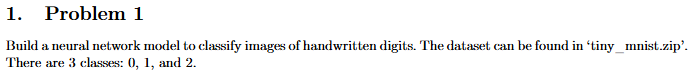

In [2]:
def im_to_array(path):
  im_list = []
  for filename in os.listdir(path):
    if filename.endswith('.png'):
      im = cv.imread(path+"/"+filename, cv.IMREAD_GRAYSCALE)
      im_list.append(im)
  return np.array(im_list).reshape(len(im_list), -1)

In [3]:
# prepare dataset
im_0 = im_to_array("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\tiny_mnist\\0")
y_0 = np.zeros(im_0.shape[0])

im_1 = im_to_array("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\tiny_mnist\\1")
y_1 = np.ones(im_1.shape[0])

im_2 = im_to_array("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\tiny_mnist\\2")
y_2 = 2*np.ones(im_2.shape[0])

X = np.concatenate((im_0, im_1, im_2), axis=0)
y = np.concatenate((y_0, y_1, y_2), axis=0)

print(X.shape)
print(y.shape)

(90, 784)
(90,)


In [4]:
# Scale X and convert array to tensor
X = X/255.0
tX = torch.tensor(X, dtype=torch.float32)
ty = torch.tensor(y, dtype=torch.long)

In [5]:
# define model
def my_ANN(X, W1, b1, W2, b2, W3, b3):
  # layer 1
  Z1 = torch.matmul(X, W1) + b1
  A1 = torch.sigmoid(Z1)

  # layer 2
  Z2 = torch.matmul(A1, W2) + b2
  A2 = torch.sigmoid(Z2)

  # output layer
  Z3 = torch.matmul(A2, W3) + b3
  return Z3

In [6]:
# Training
W1 = torch.randn(784, 16, requires_grad=True)
b1 = torch.randn(1, 16, requires_grad=True)
W2 = torch.randn(16, 8, requires_grad=True)
b2 = torch.randn(1, 8, requires_grad=True)
W3 = torch.randn(8, 3, requires_grad=True)
b3 = torch.randn(1, 3, requires_grad=True)

cost_func = nn.CrossEntropyLoss()

optimizer = optim.SGD([W1, b1, W2, b2, W3, b3], lr=0.1)

for epoch in range(1, 1001):
  Z = my_ANN(tX, W1, b1, W2, b2, W3, b3)
  loss = cost_func(Z, ty)
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

Epoch: 001, Loss: 1.9404
Epoch: 002, Loss: 1.8779
Epoch: 003, Loss: 1.8225
Epoch: 004, Loss: 1.7742
Epoch: 005, Loss: 1.7320
Epoch: 006, Loss: 1.6947
Epoch: 007, Loss: 1.6612
Epoch: 008, Loss: 1.6306
Epoch: 009, Loss: 1.6022
Epoch: 010, Loss: 1.5757
Epoch: 011, Loss: 1.5507
Epoch: 012, Loss: 1.5270
Epoch: 013, Loss: 1.5043
Epoch: 014, Loss: 1.4825
Epoch: 015, Loss: 1.4615
Epoch: 016, Loss: 1.4412
Epoch: 017, Loss: 1.4216
Epoch: 018, Loss: 1.4025
Epoch: 019, Loss: 1.3840
Epoch: 020, Loss: 1.3659
Epoch: 021, Loss: 1.3483
Epoch: 022, Loss: 1.3311
Epoch: 023, Loss: 1.3143
Epoch: 024, Loss: 1.2979
Epoch: 025, Loss: 1.2818
Epoch: 026, Loss: 1.2661
Epoch: 027, Loss: 1.2507
Epoch: 028, Loss: 1.2356
Epoch: 029, Loss: 1.2209
Epoch: 030, Loss: 1.2066
Epoch: 031, Loss: 1.1925
Epoch: 032, Loss: 1.1789
Epoch: 033, Loss: 1.1656
Epoch: 034, Loss: 1.1526
Epoch: 035, Loss: 1.1400
Epoch: 036, Loss: 1.1278
Epoch: 037, Loss: 1.1159
Epoch: 038, Loss: 1.1044
Epoch: 039, Loss: 1.0932
Epoch: 040, Loss: 1.0823


In [7]:
# Evaulate
Z = my_ANN(tX, W1, b1, W2, b2, W3, b3)
y_pred = torch.argmax(Z, dim=1)
acc = torch.mean((y_pred == ty).float())
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 100.00%


In [8]:
# Prepare test set
im_0_test = im_to_array("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\tiny_mnist\\test\\0")
y_0_test = np.zeros(im_0_test.shape[0])

im_1_test = im_to_array("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\tiny_mnist\\test\\1")
y_1_test = np.ones(im_1_test.shape[0])

im_2_test = im_to_array("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\tiny_mnist\\test\\2")
y_2_test = 2*np.ones(im_2_test.shape[0])

X_test = np.concatenate((im_0_test, im_1_test, im_2_test), axis=0)
y_test = np.concatenate((y_0_test, y_1_test, y_2_test), axis=0)

print(X_test.shape)
print(y_test.shape)


(15, 784)
(15,)


In [9]:
# Scale X_test and convert array to tensor
X_test = X_test/255.0
tX_test = torch.tensor(X_test, dtype=torch.float32)
ty_test = torch.tensor(y_test, dtype=torch.long)

In [10]:
# Evaluate test test
Z_test = my_ANN(tX_test, W1, b1, W2, b2, W3, b3)
y_pred_test = torch.argmax(Z_test, dim=1)
acc_test = torch.mean((y_pred_test == ty_test).float())
print(f"Accuracy on test set: {acc_test*100:.2f}%")

Accuracy on test set: 80.00%


In [11]:
im1 = cv.imread("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\1.png")
print(im1.shape)
im1 = cv.cvtColor(im1, cv.COLOR_BGR2GRAY)
print(im1.shape)
im1 = cv.resize(im1, (28, 28))
print(im1.shape)
im1 = im1.reshape(1, 784)/255.0
Z = my_ANN(torch.tensor(im1, dtype=torch.float32), W1, b1, W2, b2, W3, b3)
y_pred = torch.argmax(Z, dim=1)
print(y_pred)

(28, 28, 3)
(28, 28)
(28, 28)
tensor([1])


# problem 2

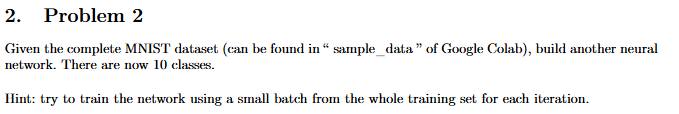

In [12]:
df_train = pd.read_csv("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\mnist_train_small.csv", header=None)
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# Split X, y, scale X, convert array to tensor
X_train = df_train.iloc[:, 1:].values/255.0
y_train = df_train.iloc[:, 0].values
tX_train = torch.tensor(X_train, dtype=torch.float32)
ty_train = torch.tensor(y_train, dtype=torch.long)
print(tX_train.shape)
print(ty_train.shape)

torch.Size([20000, 784])
torch.Size([20000])


In [14]:
# define ANN model
def my_ANN(X, W1, b1, W2, b2, W3, b3):
  # layer 1
  Z1 = torch.matmul(X, W1) + b1
  A1 = torch.sigmoid(Z1)

  # layer 2
  Z2 = torch.matmul(A1, W2) + b2
  A2 = torch.sigmoid(Z2)

  # output layer
  Z3 = torch.matmul(A2, W3) + b3
  return Z3

In [15]:
# Training
from torch.utils.data import DataLoader, TensorDataset

W1 = torch.randn(784, 64, requires_grad=True)
b1 = torch.randn(1, 64, requires_grad=True)
W2 = torch.randn(64, 32, requires_grad=True)
b2 = torch.randn(1, 32, requires_grad=True)
W3 = torch.randn(32, 10, requires_grad=True)
b3 = torch.randn(1, 10, requires_grad=True)

cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3], lr=0.1)
datset = TensorDataset(tX_train, ty_train)

for epoch in range(1, 100):
  loader = DataLoader(datset, batch_size=100, shuffle=True)
  for index, batch in enumerate(loader):
    X_batch, y_batch = batch
    Z = my_ANN(X_batch, W1, b1, W2, b2, W3, b3)
    loss = cost_func(Z, y_batch)
    loss.backward()
    optimizer.step()  
    optimizer.zero_grad()
  print(f"Batch {index:03d}th/Epoch: {epoch:03d}th, Loss: {loss.item():.4f}")

Batch 199th/Epoch: 001th, Loss: 1.5372
Batch 199th/Epoch: 002th, Loss: 1.3425
Batch 199th/Epoch: 003th, Loss: 1.1677
Batch 199th/Epoch: 004th, Loss: 0.9540
Batch 199th/Epoch: 005th, Loss: 0.7453
Batch 199th/Epoch: 006th, Loss: 0.9388
Batch 199th/Epoch: 007th, Loss: 1.0211
Batch 199th/Epoch: 008th, Loss: 0.8521
Batch 199th/Epoch: 009th, Loss: 0.7647
Batch 199th/Epoch: 010th, Loss: 0.6124
Batch 199th/Epoch: 011th, Loss: 0.6981
Batch 199th/Epoch: 012th, Loss: 0.6511
Batch 199th/Epoch: 013th, Loss: 0.4854
Batch 199th/Epoch: 014th, Loss: 0.8303
Batch 199th/Epoch: 015th, Loss: 0.6104
Batch 199th/Epoch: 016th, Loss: 0.5856
Batch 199th/Epoch: 017th, Loss: 0.6095
Batch 199th/Epoch: 018th, Loss: 0.4639
Batch 199th/Epoch: 019th, Loss: 0.4520
Batch 199th/Epoch: 020th, Loss: 0.4639
Batch 199th/Epoch: 021th, Loss: 0.6113
Batch 199th/Epoch: 022th, Loss: 0.5380
Batch 199th/Epoch: 023th, Loss: 0.3111
Batch 199th/Epoch: 024th, Loss: 0.5422
Batch 199th/Epoch: 025th, Loss: 0.3373
Batch 199th/Epoch: 026th,

In [16]:
# Evaulate on training set
Z = my_ANN(tX_train, W1, b1, W2, b2, W3, b3)
y_pred = torch.argmax(Z, dim=1)
acc = torch.mean((y_pred == ty_train).float())
print(f"Accuracy on training set: {acc*100:.2f}%")

Accuracy on training set: 94.27%


In [17]:
# Evaluate on test set
df_test = pd.read_csv("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\mnist_test.csv", header=None)
X_test = df_test.iloc[:, 1:].values/255.0
y_test = df_test.iloc[:, 0].values
tX_test = torch.tensor(X_test, dtype=torch.float32)
ty_test = torch.tensor(y_test, dtype=torch.long)

Z_test = my_ANN(tX_test, W1, b1, W2, b2, W3, b3)
y_pred_test = torch.argmax(Z_test, dim=1)
acc_test = torch.mean((y_pred_test == ty_test).float())
print(f"Accuracy on test set: {acc_test*100:.2f}%")

Accuracy on test set: 90.29%


In [18]:
# predict on a new image
im = cv.imread("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\1.png")
im = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
im = cv.resize(im, (28, 28))
im = im.reshape(1, 784)/255.0
Z = my_ANN(torch.tensor(im, dtype=torch.float32), W1, b1, W2, b2, W3, b3)
y_pred = torch.argmax(Z, dim=1)
print(f"This image is number {y_pred.item()}!")

This image is number 1!


# problem 3

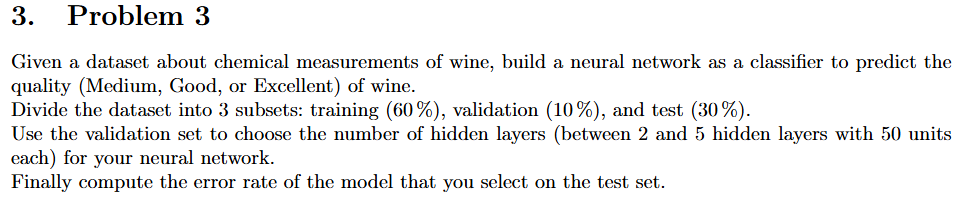

In [19]:
df = pd.read_csv("wine_quality.csv")

In [20]:
print(df.describe())
print("\nnull values:")
print(df.isnull().sum())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    4898.000000       4898.000000  4898.000000     4898.000000   
mean        6.854788          0.278241     0.334192        6.391415   
std         0.843868          0.100795     0.121020        5.072058   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.700000   
50%         6.800000          0.260000     0.320000        5.200000   
75%         7.300000          0.320000     0.390000        9.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  4898.000000          4898.000000           4898.000000  4898.000000   
mean      0.045772            35.308085            138.360657     0.994027   
std       0.021848            17.007137             42.498065     0.002991   
min       0.009000             2.000000         

In [21]:
from scipy import stats
df_clean = df[(np.abs(stats.zscore(df.iloc[:, :-1])) < 3).all(axis=1)]
print(f"removed {len(df) - len(df_clean)} outlier rows")
df = df_clean.reset_index(drop=True)

removed 396 outlier rows


In [22]:
# 1. Shuffle the entire dataframe randomly
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Calculate the split cutting points
total_rows = len(df_shuffled)
train_end = int(total_rows * 0.6)
val_end = train_end + int(total_rows * 0.1)

# 3. Slice the dataframe into 3 non-overlapping dataframes
train_df = df_shuffled.iloc[:train_end]
val_df   = df_shuffled.iloc[train_end:val_end]
test_df  = df_shuffled.iloc[val_end:]

# 4. Separate raw X (features) and raw y (labels)
wine_x_train, wine_y_train = train_df.iloc[:, :-1], train_df.iloc[:, -1]
wine_x_val, wine_y_val     = val_df.iloc[:, :-1], val_df.iloc[:, -1]
wine_x_test, wine_y_test   = test_df.iloc[:, :-1], test_df.iloc[:, -1]

# 5. Clean up and map text labels to 0, 1, 2 for ALL splits
quality_mapping = {"Medium": 0, "Good": 1, "Excellent": 2}

y_train_clean = wine_y_train.map(quality_mapping).fillna(0).astype(int)
y_val_clean   = wine_y_val.map(quality_mapping).fillna(0).astype(int)
y_test_clean  = wine_y_test.map(quality_mapping).fillna(0).astype(int)

# 6. Fit and scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(wine_x_train)
X_val_scaled   = scaler.transform(wine_x_val)       # Use transform, do not refit!
X_test_scaled  = scaler.transform(wine_x_test)     # Use transform, do not refit!

# 7. Convert everything into final PyTorch Tensors
tX_train = torch.tensor(X_train_scaled, dtype=torch.float32)
ty_train = torch.tensor(y_train_clean.values, dtype=torch.long)

tX_val   = torch.tensor(X_val_scaled, dtype=torch.float32)
ty_val   = torch.tensor(y_val_clean.values, dtype=torch.long)

tX_test  = torch.tensor(X_test_scaled, dtype=torch.float32)
ty_test  = torch.tensor(y_test_clean.values, dtype=torch.long)

print(f"Train shapes: {tX_train.shape}, {ty_train.shape}")
print(f"Val shapes:   {tX_val.shape}, {ty_val.shape}")
print(f"Test shapes:  {tX_test.shape}, {ty_test.shape}")

Train shapes: torch.Size([2701, 11]), torch.Size([2701])
Val shapes:   torch.Size([450, 11]), torch.Size([450])
Test shapes:  torch.Size([1351, 11]), torch.Size([1351])


In [23]:
print(df['quality'].value_counts())

quality
Good         2038
Medium       1443
Excellent    1021
Name: count, dtype: int64


In [24]:
def my_ANN_2layers(X, W1, b1, W2, b2, W3, b3):
    # Hidden Layer 1 (Input 11 -> 50)
    Z1 = torch.matmul(X, W1) + b1
    A1 = torch.relu(Z1)

    # Hidden Layer 2 (50 -> 50)
    Z2 = torch.matmul(A1, W2) + b2
    A2 = torch.relu(Z2)

    # Output Layer (50 -> 3)
    Z3 = torch.matmul(A2, W3) + b3
    return Z3

In [25]:
# Create, scale, then set requires_grad=True
W1 = (torch.randn(11, 50) * 0.1).detach().requires_grad_(True)
b1 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W2 = (torch.randn(50, 50) * 0.1).detach().requires_grad_(True)
b2 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W3 = (torch.randn(50, 3) * 0.1).detach().requires_grad_(True)
b3 = (torch.randn(1, 3) * 0.1).detach().requires_grad_(True)

cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3], lr=0.1)

datset = TensorDataset(tX_train, ty_train)
loader = DataLoader(datset, batch_size= 100, shuffle=True)

print("--- Training 2-Layer Model ---")
for epoch in range(1, 501):
    for index, batch in enumerate(loader):
        X_batch, y_batch = batch
        Z = my_ANN_2layers(X_batch, W1, b1, W2, b2, W3, b3)
        loss = cost_func(Z, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

--- Training 2-Layer Model ---
Epoch: 100, Loss: 0.4660
Epoch: 200, Loss: 0.0602
Epoch: 300, Loss: 0.8011
Epoch: 400, Loss: 0.1395
Epoch: 500, Loss: 0.1033


In [26]:
# Evaluate on validation set
with torch.no_grad():
    Z_val = my_ANN_2layers(tX_val, W1, b1, W2, b2, W3, b3)
    y_pred_val = torch.argmax(Z_val, dim=1)
    acc_val = torch.mean((y_pred_val == ty_val).float())

print(f"Accuracy on validation set: {acc_val*100:.2f}%")

Accuracy on validation set: 62.89%


In [27]:
def my_ANN_3layers(X, W1, b1, W2, b2, W3, b3, W4, b4):
    # Hidden Layer 1 (Input 11 -> 50)
    Z1 = torch.matmul(X, W1) + b1
    A1 = torch.relu(Z1)

    # Hidden Layer 2 (50 -> 50)
    Z2 = torch.matmul(A1, W2) + b2
    A2 = torch.relu(Z2)

    # Hidden Layer 3 (50 -> 50)
    Z3 = torch.matmul(A2, W3) + b3
    A3 = torch.relu(Z3)

    # Output Layer (50 -> 3)
    Z4 = torch.matmul(A3, W4) + b4
    return Z4

In [28]:
# Create, scale, then set requires_grad=True
W1 = (torch.randn(11, 50) * 0.1).detach().requires_grad_(True)
b1 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W2 = (torch.randn(50, 50) * 0.1).detach().requires_grad_(True)
b2 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W3 = (torch.randn(50, 50) * 0.1).detach().requires_grad_(True)
b3 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W4 = (torch.randn(50, 3) * 0.1).detach().requires_grad_(True)
b4 = (torch.randn(1, 3) * 0.1).detach().requires_grad_(True)

cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3, W4, b4], lr=0.1)

datset = TensorDataset(tX_train, ty_train)
loader = DataLoader(datset, batch_size=100, shuffle=True)

print("--- Training 3-Layer Model ---")
for epoch in range(1, 501):
    for index, batch in enumerate(loader):
        X_batch, y_batch = batch
        Z = my_ANN_3layers(X_batch, W1, b1, W2, b2, W3, b3, W4, b4)
        loss = cost_func(Z, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

--- Training 3-Layer Model ---
Epoch: 100, Loss: 0.7472
Epoch: 200, Loss: 0.3719
Epoch: 300, Loss: 0.0225
Epoch: 400, Loss: 0.0227
Epoch: 500, Loss: 0.5542


In [29]:
# Evaluate on validation set
with torch.no_grad():
    Z_val = my_ANN_3layers(tX_val, W1, b1, W2, b2, W3, b3, W4, b4)
    y_pred_val = torch.argmax(Z_val, dim=1)
    acc_val = torch.mean((y_pred_val == ty_val).float())

print(f"Accuracy on validation set: {acc_val*100:.2f}%")

Accuracy on validation set: 56.44%


In [30]:
def my_ANN_4layers(X, W1, b1, W2, b2, W3, b3, W4, b4, W5, b5):
    # Hidden Layer 1 (Input 11 -> 50)
    Z1 = torch.matmul(X, W1) + b1
    A1 = torch.relu(Z1)

    # Hidden Layer 2 (50 -> 50)
    Z2 = torch.matmul(A1, W2) + b2
    A2 = torch.relu(Z2)

    # Hidden Layer 3 (50 -> 50)
    Z3 = torch.matmul(A2, W3) + b3
    A3 = torch.relu(Z3)

    # Hidden Layer 4 (50 -> 50)
    Z4 = torch.matmul(A3, W4) + b4
    A4 = torch.relu(Z4)

    # Output Layer (50 -> 3)
    Z5 = torch.matmul(A4, W5) + b5
    return Z5

In [31]:
# Create, scale, then set requires_grad=True
W1 = (torch.randn(11, 50) * 0.1).detach().requires_grad_(True)
b1 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W2 = (torch.randn(50, 50) * 0.1).detach().requires_grad_(True)
b2 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W3 = (torch.randn(50, 50) * 0.1).detach().requires_grad_(True)
b3 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W4 = (torch.randn(50, 50) * 0.1).detach().requires_grad_(True)
b4 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W5 = (torch.randn(50, 3) * 0.1).detach().requires_grad_(True)
b5 = (torch.randn(1, 3) * 0.1).detach().requires_grad_(True)

cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3, W4, b4, W5, b5], lr=0.1)

datset = TensorDataset(tX_train, ty_train)
loader = DataLoader(datset, batch_size=100, shuffle=True)

print("--- Training 4-Layer Model ---")
for epoch in range(1, 501):
    for index, batch in enumerate(loader):
        X_batch, y_batch = batch
        Z = my_ANN_4layers(X_batch, W1, b1, W2, b2, W3, b3, W4, b4, W5, b5)
        loss = cost_func(Z, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

--- Training 4-Layer Model ---
Epoch: 100, Loss: 0.5604
Epoch: 200, Loss: 1.5604
Epoch: 300, Loss: 0.0019
Epoch: 400, Loss: 0.1473
Epoch: 500, Loss: 0.1711


In [32]:
# Evaluate on validation set
with torch.no_grad():
    Z_val = my_ANN_4layers(tX_val, W1, b1, W2, b2, W3, b3, W4, b4, W5, b5)
    y_pred_val = torch.argmax(Z_val, dim=1)
    acc_val = torch.mean((y_pred_val == ty_val).float())

print(f"Accuracy on validation set: {acc_val*100:.2f}%")

Accuracy on validation set: 62.89%


In [33]:

def my_ANN_5layers(X, W1, b1, W2, b2, W3, b3, W4, b4, W5, b5, W6, b6):
    # Hidden Layer 1 (Input 11 -> 50)
    Z1 = torch.matmul(X, W1) + b1
    A1 = torch.relu(Z1)

    # Hidden Layer 2 (50 -> 50)
    Z2 = torch.matmul(A1, W2) + b2
    A2 = torch.relu(Z2)

    # Hidden Layer 3 (50 -> 50)
    Z3 = torch.matmul(A2, W3) + b3
    A3 = torch.relu(Z3)

    # Hidden Layer 4 (50 -> 50)
    Z4 = torch.matmul(A3, W4) + b4
    A4 = torch.relu(Z4)

    # Hidden Layer 5 (50 -> 50)
    Z5 = torch.matmul(A4, W5) + b5
    A5 = torch.relu(Z5)

    # Output Layer (50 -> 3)
    Z6 = torch.matmul(A5, W6) + b6
    return Z6

In [34]:
# Create, scale, then set requires_grad=True
W1 = (torch.randn(11, 50) * 0.1).detach().requires_grad_(True)
b1 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W2 = (torch.randn(50, 50) * 0.1).detach().requires_grad_(True)
b2 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W3 = (torch.randn(50, 50) * 0.1).detach().requires_grad_(True)
b3 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W4 = (torch.randn(50, 50) * 0.1).detach().requires_grad_(True)
b4 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W5 = (torch.randn(50, 50) * 0.1).detach().requires_grad_(True)
b5 = (torch.randn(1, 50) * 0.1).detach().requires_grad_(True)
W6 = (torch.randn(50, 3) * 0.1).detach().requires_grad_(True)
b6 = (torch.randn(1, 3) * 0.1).detach().requires_grad_(True)

cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3, W4, b4, W5, b5, W6, b6], lr=0.1)

datset = TensorDataset(tX_train, ty_train)
loader = DataLoader(datset, batch_size=1000, shuffle=True)

print("--- Training 5-Layer Model ---")
for epoch in range(1, 501):
    for index, batch in enumerate(loader):
        X_batch, y_batch = batch
        Z = my_ANN_5layers(X_batch, W1, b1, W2, b2, W3, b3, W4, b4, W5, b5, W6, b6)
        loss = cost_func(Z, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

--- Training 5-Layer Model ---
Epoch: 100, Loss: 0.9152
Epoch: 200, Loss: 0.7865
Epoch: 300, Loss: 0.8162
Epoch: 400, Loss: 0.7595
Epoch: 500, Loss: 0.7192


In [35]:
# Evaluate on validation set
with torch.no_grad():
    Z_val = my_ANN_5layers(tX_val, W1, b1, W2, b2, W3, b3, W4, b4, W5, b5,W6,b6)
    y_pred_val = torch.argmax(Z_val, dim=1)
    acc_val = torch.mean((y_pred_val == ty_val).float())

print(f"Accuracy on validation set: {acc_val*100:.2f}%")

Accuracy on validation set: 59.78%


## the best model is the the 3 layers model with 65% accuracy.

In [36]:
# Evaluate on validation set
with torch.no_grad():
    Z_test = my_ANN_3layers(tX_test, W1, b1, W2, b2, W3, b3,W4,b4)
    y_pred_test = torch.argmax(Z_test, dim=1)
    acc_test = torch.mean((y_pred_test == ty_test).float())

print(f"Accuracy on test set: {acc_test*100:.2f}%")

Accuracy on test set: 0.00%


# problem 4

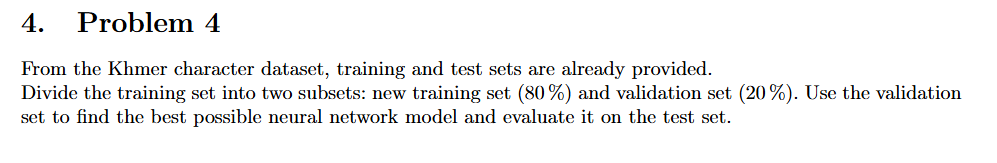

In [37]:
kh_train = pd.read_csv("kh_char_train.csv")
kh_test = pd.read_csv("kh_char_test.csv")

In [38]:
kh_train.head()

,CHHO,218,206,194,194.1,214,214.1,210,218.1,198,...,194.141,48.5,0.110,202.95,198.121,198.122,198.123,202.96,198.124,202.97
0,TA,241,241,255,255,255,255,255,255,255,...,0,13,45,81,122,136,145,159,163,163
1,NGO,183,163,122,142,142,163,163,163,193,...,142,173,183,183,153,142,142,163,153,153
2,KO,200,204,212,216,212,212,204,204,208,...,135,142,135,142,146,142,131,123,146,154
3,NGO,178,178,178,178,178,178,165,178,191,...,216,216,216,216,204,216,216,216,216,216
4,TA,191,181,186,186,186,196,196,196,201,...,191,191,186,73,0,0,9,127,156,171


In [39]:
kh_train_x = kh_train.iloc[:, 1:]
kh_train_y = kh_train.iloc[:, 0]
kh_test_x = kh_test.iloc[:, 1:]
kh_test_y = kh_test.iloc[:, 0]

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. split
kh_x_train, kh_x_val, kh_y_train, kh_y_val = train_test_split(
    kh_train_x, kh_train_y, test_size=0.2, random_state=42
)

# 2. scale
scaler = StandardScaler()
kh_x_train_scaled = scaler.fit_transform(kh_x_train.values)
kh_x_val_scaled   = scaler.transform(kh_x_val.values)
kh_x_test_scaled  = scaler.transform(kh_test_x.values)

# 3. PCA
pca = PCA(n_components=500)
kh_x_train_pca = pca.fit_transform(kh_x_train_scaled)
kh_x_val_pca   = pca.transform(kh_x_val_scaled)
kh_x_test_pca  = pca.transform(kh_x_test_scaled)

print(f"variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

variance retained: 96.2%


In [41]:
# after your split, before encoding
mask_train = kh_y_train.notna()
kh_x_train_pca = kh_x_train_pca[mask_train]
kh_y_train = kh_y_train[mask_train]

mask_val = kh_y_val.notna()
kh_x_val_pca = kh_x_val_pca[mask_val]
kh_y_val = kh_y_val[mask_val]

mask_test = kh_test_y.notna()
kh_x_test_pca = pca.transform(scaler.transform(kh_test_x.values))[mask_test.values]
kh_test_y = kh_test_y[mask_test]

In [42]:
kh_train_y.unique()

array(['TA', 'NGO', 'KO', 'KHA', 'CHA', nan, 'DA', 'CHHA', 'KHO', 'CHHO'],
      dtype=object)

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
kh_y_train_enc = le.fit_transform(kh_y_train)
kh_y_val_enc   = le.transform(kh_y_val)
kh_y_test_enc  = le.transform(kh_test_y)

In [44]:
def my_ANN_kh(X, W1, b1, W2, b2, W3, b3, W4, b4):
    Z1 = torch.matmul(X, W1) + b1
    A1 = torch.relu(Z1)
    Z2 = torch.matmul(A1, W2) + b2
    A2 = torch.relu(Z2)
    Z3 = torch.matmul(A2, W3) + b3
    A3 = torch.relu(Z3)
    Z4 = torch.matmul(A3, W4) + b4
    return Z4

cost_func = nn.CrossEntropyLoss()
optimizer = optim.Adam([W1,b1,W2,b2,W3,b3,W4,b4], lr=0.001)

In [45]:
# Create, scale, then set requires_grad=True
W1 = (torch.randn(500, 128) * 0.1).detach().requires_grad_(True)
b1 = torch.zeros(1, 128, requires_grad=True)
W2 = (torch.randn(128, 128) * 0.1).detach().requires_grad_(True)
b2 = torch.zeros(1, 128, requires_grad=True)
W3 = (torch.randn(128, 128) * 0.1).detach().requires_grad_(True)
b3 = torch.zeros(1, 128, requires_grad=True)
W4 = (torch.randn(128, 9) * 0.1).detach().requires_grad_(True)
b4 = torch.zeros(1, 9, requires_grad=True)

cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3, W4, b4], lr=0.05)

tX_train = torch.tensor(kh_x_train_pca, dtype=torch.float32)
ty_train = torch.tensor(kh_y_train_enc, dtype=torch.long)

datset = TensorDataset(tX_train, ty_train)
loader = DataLoader(datset, batch_size=100, shuffle=True)


for epoch in range(1, 301):
    for index, batch in enumerate(loader):
        X_batch, y_batch = batch
        Z = my_ANN_kh(X_batch, W1, b1, W2, b2, W3, b3, W4, b4)
        loss = cost_func(Z, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

Epoch: 100, Loss: 0.0005
Epoch: 200, Loss: 0.0002
Epoch: 300, Loss: 0.0001


In [46]:
# Evaluate on validation set
tX_val = torch.tensor(kh_x_val_pca, dtype=torch.float32)
with torch.no_grad():
    Z_val = my_ANN_kh(tX_val, W1, b1, W2, b2, W3, b3, W4, b4)
    kh_y_val_enc_pred = torch.argmax(Z_val, dim=1)
    acc_val = torch.mean((kh_y_val_enc_pred == kh_y_val_enc).float())

print(f"Accuracy on validation set: {acc_val*100:.2f}%")

Accuracy on validation set: 83.39%


In [47]:
# Evaluate on validation set
tX_test = torch.tensor(kh_x_test_pca, dtype=torch.float32)
with torch.no_grad():
    Z_test = my_ANN_kh(tX_test, W1, b1, W2, b2, W3, b3, W4, b4)
    kh_y_test_enc_pred = torch.argmax(Z_test, dim=1)
    acc_val = torch.mean((kh_y_test_enc_pred == kh_y_test_enc).float())

print(f"Accuracy on validation set: {acc_val*100:.2f}%")

Accuracy on validation set: 83.04%


good enough i dc.

# problem 5

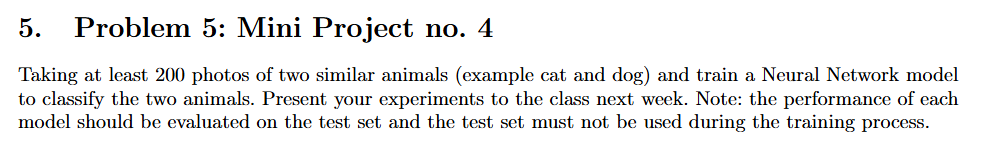

In [48]:
def im_to_array(path, size=(128, 128)):
    im_list = []
    for filename in os.listdir(path):
        if filename.endswith('.png'):
            im = cv.imread(path + "/" + filename, cv.IMREAD_GRAYSCALE)  # grayscale
            im = cv.resize(im, size)
            im_list.append(im)
    return np.array(im_list).reshape(len(im_list), -1)

cat = im_to_array("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\animal\\train\\cats")
cat_y = np.zeros(cat.shape[0])

dog = im_to_array("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\animal\\train\\dogs")
dog_y = np.ones(dog.shape[0])

X5_train = np.concatenate((cat, dog), axis=0)
y5_train = np.concatenate((cat_y, dog_y), axis=0)

print(X5_train.shape)  # should be (200, 4096)
print(y5_train.shape)  # should be (200,)

(1010, 16384)
(1010,)


0 = cat

1 = dog

In [49]:
cat_test = im_to_array("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\animal\\valid\\cats")
cat_y_test = np.zeros(cat_test.shape[0])

dog_test = im_to_array("C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\animal\\valid\\dogs")
dog_y_test = np.ones(dog_test.shape[0])

X5_test = np.concatenate((cat_test, dog_test), axis=0)
y5_test = np.concatenate((cat_y_test, dog_y_test), axis=0)

print(X5_test.shape)
print(y5_test.shape)  

(123, 16384)
(123,)


In [50]:
# 1. scale
scaler = StandardScaler()
x5_train_scaled = scaler.fit_transform(X5_train)
x5_test_scaled  = scaler.transform(X5_test)
# 2. PCA
pca = PCA(n_components=100)
x5_train_pca = pca.fit_transform(x5_train_scaled)
x5_test_pca  = pca.transform(x5_test_scaled)

print(f"variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

variance retained: 86.2%


In [51]:
x5_train_pca

array([[-73.63921674,  13.36047489, -61.42934685, ...,   3.29370728,
          2.21678901,   2.89588043],
       [-73.48086357,  15.87628107, -37.36156865, ...,  -4.23849116,
         -4.88790667,  -4.79638086],
       [ 87.87058224, -11.39373914,  65.72533795, ...,  -3.54044914,
         -2.11947235,  -3.0056071 ],
       ...,
       [ 17.95529009, -20.53696168,  48.52800783, ...,  -0.14240199,
          4.09643964,   1.28424943],
       [ -2.27335674, -14.24544698, -15.09727156, ...,   0.10996126,
         -2.67488808,   1.00538082],
       [ -1.41702518, -44.30994257, -33.33607478, ...,  -1.94204314,
         -1.01188906,   6.64665225]], shape=(1010, 100))

In [52]:
def my_ANN_5(X, W1, b1, W2, b2, W3, b3, W4, b4):
    Z1 = torch.matmul(X, W1) + b1
    A1 = torch.sigmoid(Z1)
    Z2 = torch.matmul(A1, W2) + b2
    A2 = torch.sigmoid(Z2)
    Z3 = torch.matmul(A2, W3) + b3
    A3 = torch.sigmoid(Z3)
    Z4 = torch.matmul(A3, W4) + b4
    return Z4

cost_func = nn.CrossEntropyLoss()
optimizer = optim.Adam([W1,b1,W2,b2,W3,b3,W4,b4], lr=0.001)

In [53]:
# Create, scale, then set requires_grad=True
W1 = (torch.randn(100, 128) * 0.1).detach().requires_grad_(True)
b1 = torch.zeros(1, 128, requires_grad=True)
W2 = (torch.randn(128, 128) * 0.1).detach().requires_grad_(True)
b2 = torch.zeros(1, 128, requires_grad=True)
W3 = (torch.randn(128, 128) * 0.1).detach().requires_grad_(True)
b3 = torch.zeros(1, 128, requires_grad=True)
W4 = (torch.randn(128, 2) * 0.1).detach().requires_grad_(True) 
b4 = torch.zeros(1, 2, requires_grad=True)
cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3, W4, b4], lr=0.01)   

tX_train = torch.tensor(x5_train_pca, dtype=torch.float32)
ty_train = torch.tensor(y5_train, dtype=torch.long)

datset = TensorDataset(tX_train, ty_train)
loader = DataLoader(datset, batch_size=100, shuffle=True)


for epoch in range(1, 201):
    for index, batch in enumerate(loader):
        X_batch, y_batch = batch
        Z = my_ANN_5(X_batch, W1, b1, W2, b2, W3, b3, W4, b4)
        loss = cost_func(Z, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

Epoch: 100, Loss: 0.6644
Epoch: 200, Loss: 0.6743


In [54]:
tX_test = torch.tensor(x5_test_pca, dtype=torch.float32)
ty_test = torch.tensor(y5_test, dtype=torch.long)

with torch.no_grad():
    Z_test = my_ANN_5(tX_test, W1, b1, W2, b2, W3, b3, W4, b4)
    y5_pred = torch.argmax(Z_test, dim=1)
    acc_test = torch.mean((y5_pred == ty_test).float())

print(f"Accuracy on test set: {acc_test*100:.2f}%")

Accuracy on test set: 57.72%
